In [ ]:
import pathlib

In [ ]:
import marimo as mo
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-06-17T14:14:05.381625+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1052-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

matplotlib: 3.10.7
numpy     : 2.1.2
pandas    : 2.2.3
seaborn   : 0.13.2
requests  : 2.34.2
teeplot   : 1.4.2
marimo    : 0.23.2

```

## Data

Load the per-replicate **strain** and **Hamming-weight** prevalence
time series produced by the 3-site mutation-rate sweep slurm job
(`slurm/2026-06-17/2026-06-17-3site-mutation-sweep.sh`, driven by
notebook `bindle/2026-05-20-founder.py`), cached as parquets on OSF.
The sweep fixes `N_SITES=3` and steps `MUTATION_RATE` across a
geometric grid of 17 conditions spanning `1e-9` to `1e-1` (~2 points
per decade), with a handful of replicates retained per rate at 5000
steps each, POP_SIZE=1_000_000, on CPU (engine=numpy).

Two long-form frames back this notebook, keyed by the shared
`replicate_uid` and `Step`:

- **strain** (`f4bzv`): one row per `(replicate_uid, Step, strain)`
  genome (`strain` in `0 .. 2**N_SITES - 1`), with per-genome
  prevalence `count` (population fraction) and raw case count
  `n_cases`. A strain's Hamming weight is its genome bit-count ---
  the number of mutations separating it from the all-zero founder.
- **hw** (`4mrgu`): one row per `(replicate_uid, Step, hw)`
  Hamming-weight band (`hw` in `0 .. N_SITES`), aggregating the
  per-genome counts into the per-weight prevalence `count`. Each
  band equals the sum of its same-weight strains.

Both slugs are downloaded with `requests` and cached at `/tmp/<slug>`
so re-runs hit the local copy.

In [ ]:
# CLI args. Defaults pull the 3-site mutation-sweep strain + hw
# trajectory parquets that back this notebook.
_args = mo.cli_args()
OSF_SLUG_STRAIN = str(_args.get("osf-slug-strain") or "f4bzv")
OSF_SLUG_HW = str(_args.get("osf-slug-hw") or "4mrgu")
print(
    f"args: OSF_SLUG_STRAIN={OSF_SLUG_STRAIN} OSF_SLUG_HW={OSF_SLUG_HW}",
)

args: OSF_SLUG_STRAIN=f4bzv OSF_SLUG_HW=4mrgu


In [ ]:
def _fetch(slug):
    cache_path = pathlib.Path("/tmp") / slug
    url = f"https://osf.io/{slug}/download"
    if not cache_path.exists():
        print(f"downloading {url} -> {cache_path}")
        resp = requests.get(url, allow_redirects=True, timeout=240)
        resp.raise_for_status()
        cache_path.write_bytes(resp.content)
    else:
        print(f"reusing cached {cache_path}")
    print(f"size: {cache_path.stat().st_size} bytes")
    return pd.read_parquet(cache_path)

strain_df = _fetch(OSF_SLUG_STRAIN)
hw_df = _fetch(OSF_SLUG_HW)
print(f"loaded strain dataframe: {strain_df.shape}")
print(f"loaded hw dataframe: {hw_df.shape}")
print(
    "mutation_rate x replicate counts (hw):\n"
    + str(hw_df.groupby("mutation_rate")["replicate_uid"].nunique()),
)

downloading https://osf.io/f4bzv/download -> /tmp/f4bzv
size: 32413059 bytes
downloading https://osf.io/4mrgu/download -> /tmp/4mrgu
size: 8169481 bytes
loaded strain dataframe: (2680000, 23)
loaded hw dataframe: (1340000, 20)
mutation_rate x replicate counts (hw):
mutation_rate
1.000000e-09    4
3.000000e-09    4
1.000000e-08    4
3.000000e-08    4
1.000000e-07    4
               ..
1.000000e-03    4
3.000000e-03    4
1.000000e-02    4
3.000000e-02    4
1.000000e-01    4
Name: replicate_uid, Length: 17, dtype: int64


## Trellis Layout & Hamming-Weight Coloring

Tag every strain genome with its **Hamming weight** (`bit-count`) so
the per-genome curves can be colored by weight, matching the
aggregated `hw` bands. Then build the trellis index: replicates are
arranged with **one row per `mutation_rate`** (ascending) and **one
column per within-rate replicate** (ordered by `replicate_uid`), so
each panel is a single replicate's full trajectory and reading down a
column walks the mutation-rate sweep.

The per-step series are subsampled by `STRIDE` for plotting (the
endemic curves are smooth, so thinning to ~1000 points per line keeps
the figure light without changing its shape).

In [ ]:
N_SITES = int(hw_df["n_sites"].iloc[0])
STRIDE = max(1, int(strain_df["Step"].nunique()) // 1000)

# Hamming weight of each genome == popcount of the strain index.
strain_hw_df = strain_df.assign(
    hw=strain_df["strain"].map(lambda _s: bin(int(_s)).count("1")),
)

# Row = mutation_rate (ascending); column = within-rate replicate
# rank (ordered by replicate_uid for determinism).
rate_vals = sorted(hw_df["mutation_rate"].unique().tolist())
reps_by_rate = {
    _rate: sorted(
        hw_df[hw_df["mutation_rate"] == _rate]["replicate_uid"].unique(),
    )
    for _rate in rate_vals
}
max_reps = max(len(_r) for _r in reps_by_rate.values())
print(f"N_SITES={N_SITES} STRIDE={STRIDE}")
print(
    f"grid: {len(rate_vals)} rates (rows) x {max_reps} replicates (cols)"
)

N_SITES=3 STRIDE=5
grid: 17 rates (rows) x 4 replicates (cols)


## Replicate Trajectory Trellis

One panel per replicate, trellised by `mutation_rate` (rows, log-
spaced sweep) over within-rate replicates (columns). In each panel:

- **solid** lines are individual **strain** (per-genome) prevalence
  trajectories, **color-coded by Hamming weight**;
- **dashed** lines are the aggregated **Hamming-weight band**
  prevalences in the same color scheme.

These are individual replicate trajectories, so **no confidence
interval** is drawn --- every line is one realized run. The dashed
band of a given color is the sum of the solid strain curves sharing
that Hamming weight.

teeplots/2026-06-17-3site-strain-trajectories/a=strain-vs-hw-replicate-trellis+viz=subplots+ext=.pdf
teeplots/2026-06-17-3site-strain-trajectories/a=strain-vs-hw-replicate-trellis+viz=subplots+ext=.png


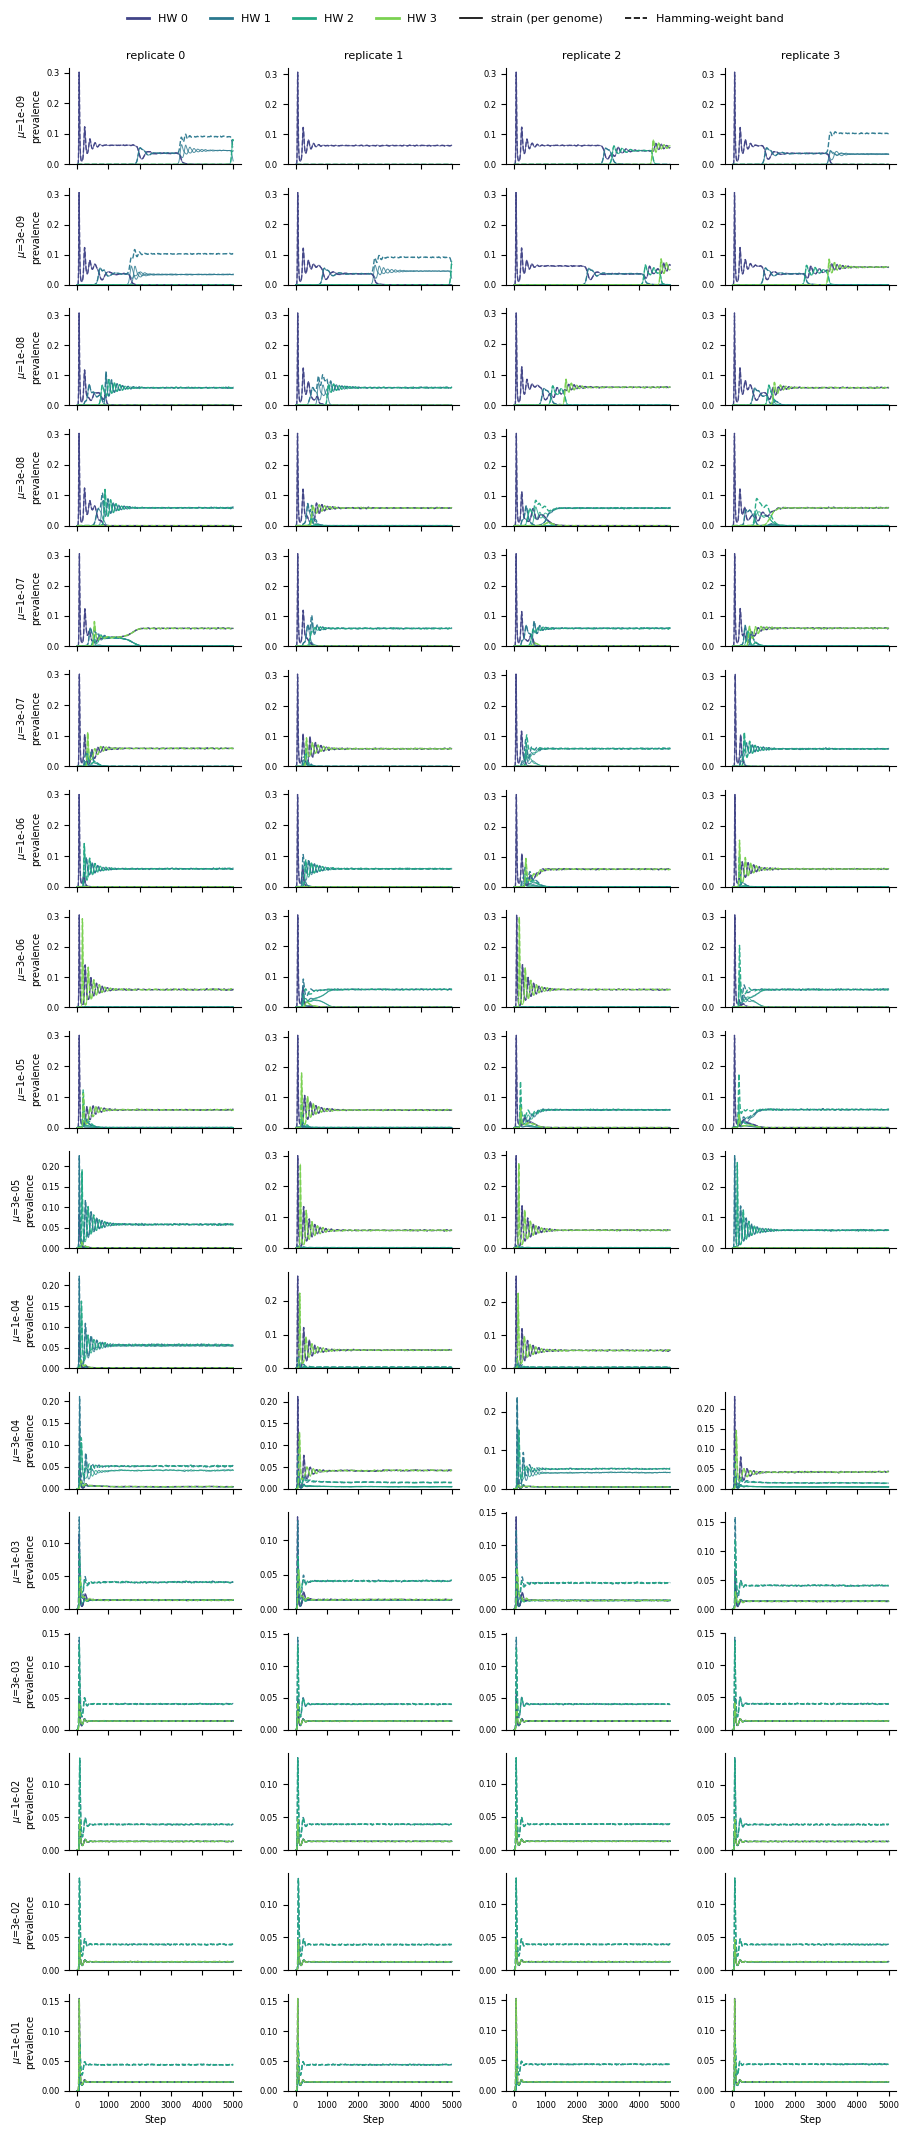

In [ ]:
_hw_colors = sns.color_palette("viridis", N_SITES + 1)
_n_rows = len(rate_vals)
_n_cols = int(max_reps)

with tp.teed(
    plt.subplots,
    nrows=_n_rows,
    ncols=_n_cols,
    figsize=(2.3 * _n_cols, 1.25 * _n_rows),
    sharex=True,
    squeeze=False,
    teeplot_outattrs={"a": "strain-vs-hw-replicate-trellis"},
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as (_fig, _axes):
    for _i, _rate in enumerate(rate_vals):
        _reps = reps_by_rate[_rate]
        for _j in range(_n_cols):
            _ax = _axes[_i][_j]
            if _j >= len(_reps):
                _ax.axis("off")
                continue
            _rid = _reps[_j]
            _h = hw_df[hw_df["replicate_uid"] == _rid].sort_values("Step")
            _s = strain_hw_df[
                strain_hw_df["replicate_uid"] == _rid
            ].sort_values("Step")

            # Solid: per-genome strain prevalence, colored by hw.
            for _strain in sorted(_s["strain"].unique()):
                _ss = _s[_s["strain"] == _strain].iloc[::STRIDE]
                _w = bin(int(_strain)).count("1")
                _ax.plot(
                    _ss["Step"],
                    _ss["count"],
                    linestyle="-",
                    linewidth=0.7,
                    color=_hw_colors[_w],
                    alpha=0.8,
                )
            # Dashed: aggregated Hamming-weight band prevalence.
            for _w in range(N_SITES + 1):
                _hh = _h[_h["hw"] == _w].iloc[::STRIDE]
                _ax.plot(
                    _hh["Step"],
                    _hh["count"],
                    linestyle="--",
                    linewidth=1.0,
                    color=_hw_colors[_w],
                    alpha=0.95,
                )

            _ax.set_ylim(bottom=0)
            _ax.tick_params(labelsize=6)
            if _j == 0:
                _ax.set_ylabel(
                    f"$\\mu$={_rate:.0e}\nprevalence",
                    fontsize=7,
                )
            if _i == 0:
                _ax.set_title(f"replicate {_j}", fontsize=8)
            if _i == _n_rows - 1:
                _ax.set_xlabel("Step", fontsize=7)
            sns.despine(ax=_ax)

    # Shared legend: Hamming-weight colors + line-style meaning.
    _handles = [
        mlines.Line2D(
            [],
            [],
            color=_hw_colors[_w],
            linewidth=2.0,
            label=f"HW {_w}",
        )
        for _w in range(N_SITES + 1)
    ]
    _handles += [
        mlines.Line2D(
            [],
            [],
            color="black",
            linestyle="-",
            linewidth=1.2,
            label="strain (per genome)",
        ),
        mlines.Line2D(
            [],
            [],
            color="black",
            linestyle="--",
            linewidth=1.2,
            label="Hamming-weight band",
        ),
    ]
    _fig.legend(
        handles=_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.005),
        ncol=len(_handles),
        frameon=False,
        fontsize=8,
    )
    _fig.tight_layout(rect=(0, 0, 1, 0.99))